# EDOL dataset


In [3]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from evclust.datasets import load_edol
import math
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from evclust.wecm_new_barycenter_2 import wecm as wecm2

In [9]:
def display_evaluation_metrics(X, models, alg="evidential", up_low_appr=True, cex=25):
    if alg == "evidential":
        predicted_labels_list = list(map(lambda model: np.argmax(model['betp'], axis=1), models))
    else:
        predicted_labels_list = list(map(lambda model: np.argmax(model['fuzzy_part'], axis=1), models))
    silhouette_scores = [silhouette_score(X, predicted_labels, metric="euclidean") for predicted_labels in predicted_labels_list]
    return silhouette_scores

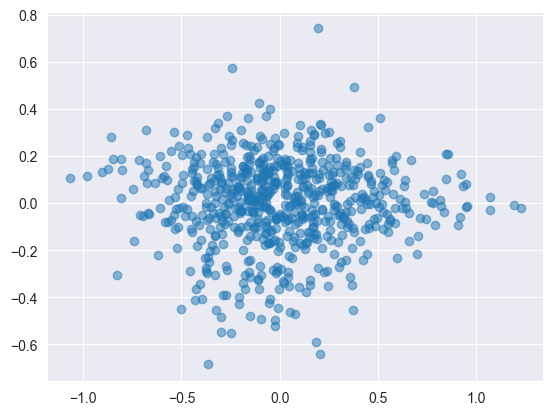

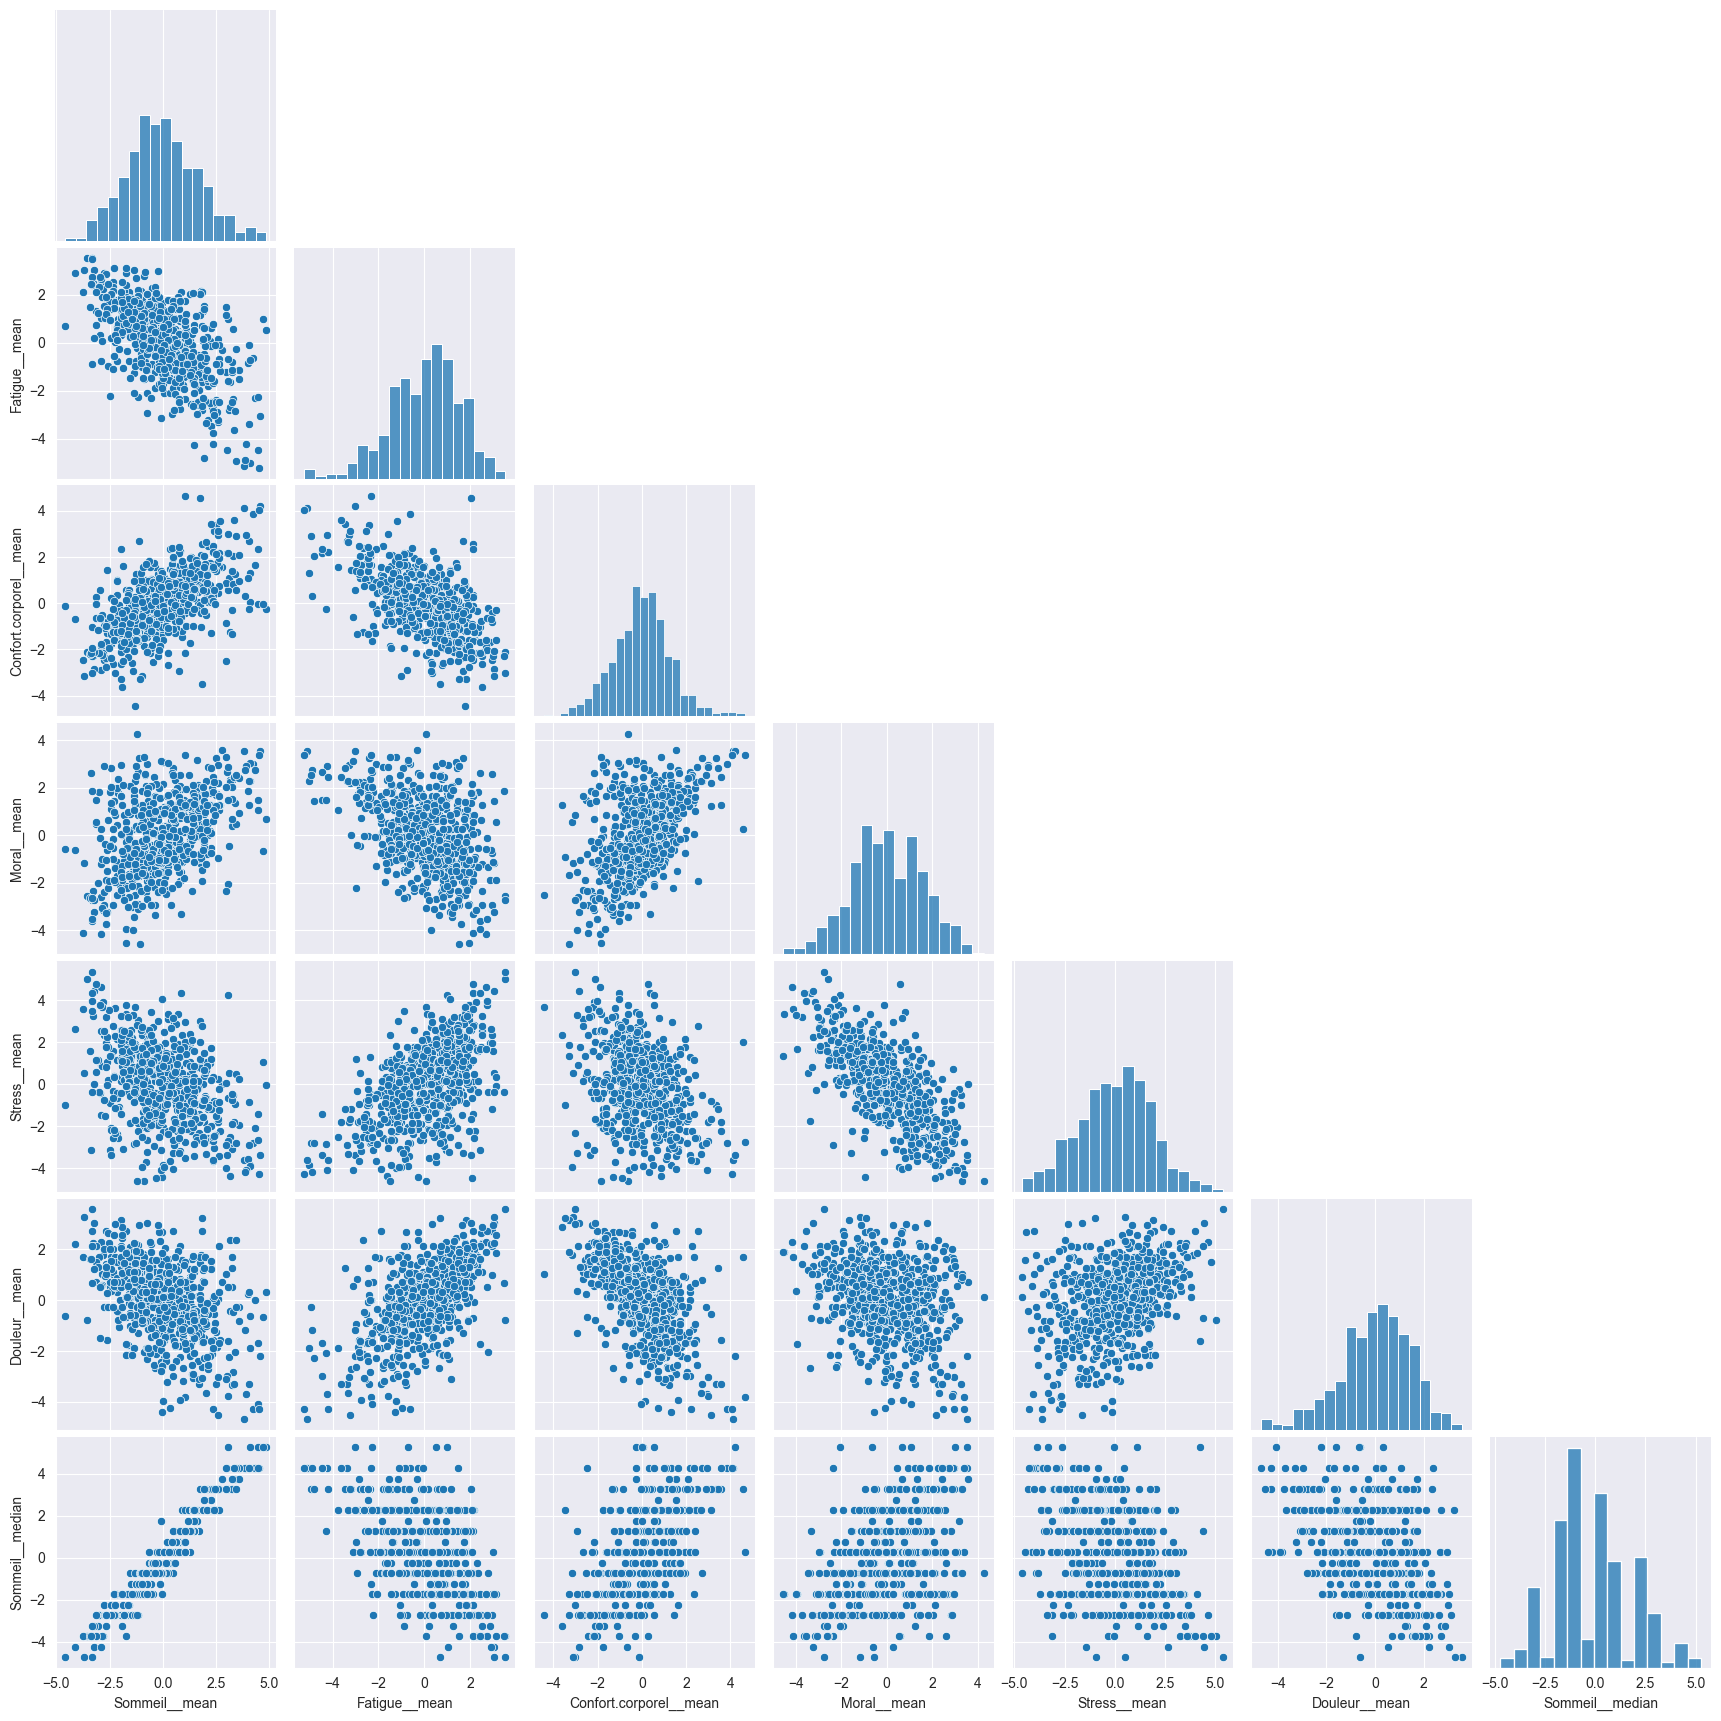

In [5]:

# fetch dataset
df = load_edol()
X = pd.DataFrame(df.iloc[:, 1:])

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

# Perform PCA for dimensionality reduction
pca = PCA(n_components=2)  # Reduce to 2 dimensions
data_reduced = pca.fit_transform(X)
variance_percent = np.round(pca.explained_variance_ratio_ * 100, 1)
# for i in range(data_reduced.shape[0]):
plt.scatter(data_reduced[:, 0], data_reduced[:, 1], alpha=0.5)

sns.pairplot(df, corner=True)

c = 2


## WECM2

In [11]:
%%capture
wecm2_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
wecm2_models_list = {}
for c in [2, 3, 4]:
    for i in range(5):
        model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-5)
        wecm2_models = np.append(wecm2_models, model)
    
    wecm2_models = sorted(wecm2_models, key=lambda model: model['crit'])
    wecm2_models_list[c] = wecm2_models

In [12]:
for c, models in wecm2_models_list.items():
    print(f"{c} clusters: {display_evaluation_metrics(X, models)}")

2 clusters: [0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184]
3 clusters: [0.19419741436208193, 0.19479982976908974, 0.19479982976908974, 0.19479982976908974, 0.19479982976908974, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184]
4 clusters: [0.11906738995088971, 0.11862067296937645, 0.1193855731930283, 0.12330861934606546, 0.19419741436208193, 0.19479982976908974, 0.19479982976908974, 0.19479982976908974, 0.19479982976908974, 0.14922051870425188, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184]
